In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/mahina_01.MOV
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/VID-20251113-WA0235.mp4
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/VID-20251113-WA0167.mp4
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/20251202_145334.mp4
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/mahina_09.MOV
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/mahina_14.MOV
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/20251113_101039.mp4
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/20251112_140222.mp4
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/mahina_16.MOV
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset/mahina/mahina_17.MOV
/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/

In [2]:
import os
import shutil

# Sab kuch delete kar dein taake 20GB space wapis mil jaye
working_dir = '/kaggle/working'
for item in os.listdir(working_dir):
    item_path = os.path.join(working_dir, item)
    try:
        if os.path.isdir(item_path):
            shutil.rmtree(item_path)
        else:
            os.remove(item_path)
    except Exception as e:
        print(f"Could not delete {item}: {e}")

print("Storage Cleaned! Ab aap ke paas poori space available hai.")

Storage Cleaned! Ab aap ke paas poori space available hai.


In [3]:
import os
import numpy as np
import pickle
from sklearn.model_selection import train_test_split

input_folder = '/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset'

classes = sorted([d for d in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, d))])
label_map = {cls: idx for idx, cls in enumerate(classes)}

np.save('/kaggle/working/master_label_map.npy', label_map)
with open('/kaggle/working/master_label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

all_video_paths = []
all_labels = []

for cls in classes:
    cls_path = os.path.join(input_folder, cls)
    for vid in os.listdir(cls_path):
        if vid.lower().endswith(('.mp4', '.mov', '.avi')):
            all_video_paths.append(os.path.join(cls_path, vid))
            all_labels.append(cls)

train_vids, test_vids, train_labels, test_labels = train_test_split(
    all_video_paths, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)
val_vids, test_vids, val_labels, test_labels = train_test_split(
    test_vids, test_labels, test_size=0.50, random_state=42, stratify=test_labels
)

print(f"Total Videos: {len(all_video_paths)}")
print(f"Split sizes -> Train: {len(train_vids)}, Val: {len(val_vids)}, Test: {len(test_vids)}")

Total Videos: 4000
Split sizes -> Train: 2800, Val: 600, Test: 600


In [4]:
import cv2
import numpy as np
import os
import shutil
import gc
from tqdm import tqdm

IMG_SIZE = 224
SEQUENCE_LENGTH = 16 

def process_video_v3(video_path):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if not cap.isOpened() or total_frames < 5:
        return None
    
    temp_frames = []
    
    # Pura video read karein, no 15% drop
    while True:
        ret, frame = cap.read()
        if not ret: break
        
        frame = cv2.GaussianBlur(frame, (3, 3), 0)
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 
        frame = frame.astype(np.float32) / 255.0
        temp_frames.append(frame)
        
    cap.release()

    if len(temp_frames) < 1: return None
    
    # Uniformly sample 16 frames across the entire video
    idx = np.linspace(0, len(temp_frames) - 1, SEQUENCE_LENGTH, dtype=int)
    sampled = np.array([temp_frames[i] for i in idx], dtype=np.float16)
    
    del temp_frames # Memory free karein
    return sampled

def process_and_save_group(vids, labels, split_name):
    output_base = '/kaggle/working/processed_sign_data'
    print(f"\nProcessing {split_name} split...")
    for vid_path, cls in tqdm(zip(vids, labels), total=len(vids)):
        data = process_video_v3(vid_path)
        if data is not None:
            save_path = os.path.join(output_base, split_name, cls)
            os.makedirs(save_path, exist_ok=True)
            file_name = os.path.basename(vid_path).rsplit('.', 1)[0] + '.npz'
            np.savez_compressed(os.path.join(save_path, file_name), data=data, label=label_map[cls])
            del data
    gc.collect() # Force garbage collection after each split to avoid RAM crash

if os.path.exists('/kaggle/working/processed_sign_data'):
    shutil.rmtree('/kaggle/working/processed_sign_data')

process_and_save_group(train_vids, train_labels, 'train')
process_and_save_group(val_vids, val_labels, 'val')
process_and_save_group(test_vids, test_labels, 'test')


Processing train split...


100%|██████████| 2800/2800 [1:09:21<00:00,  1.49s/it]



Processing val split...


100%|██████████| 600/600 [14:02<00:00,  1.40s/it]



Processing test split...


100%|██████████| 600/600 [13:15<00:00,  1.33s/it]


Showing Sign: likhna (Label: 31)
Data Shape: (16, 224, 224, 3)


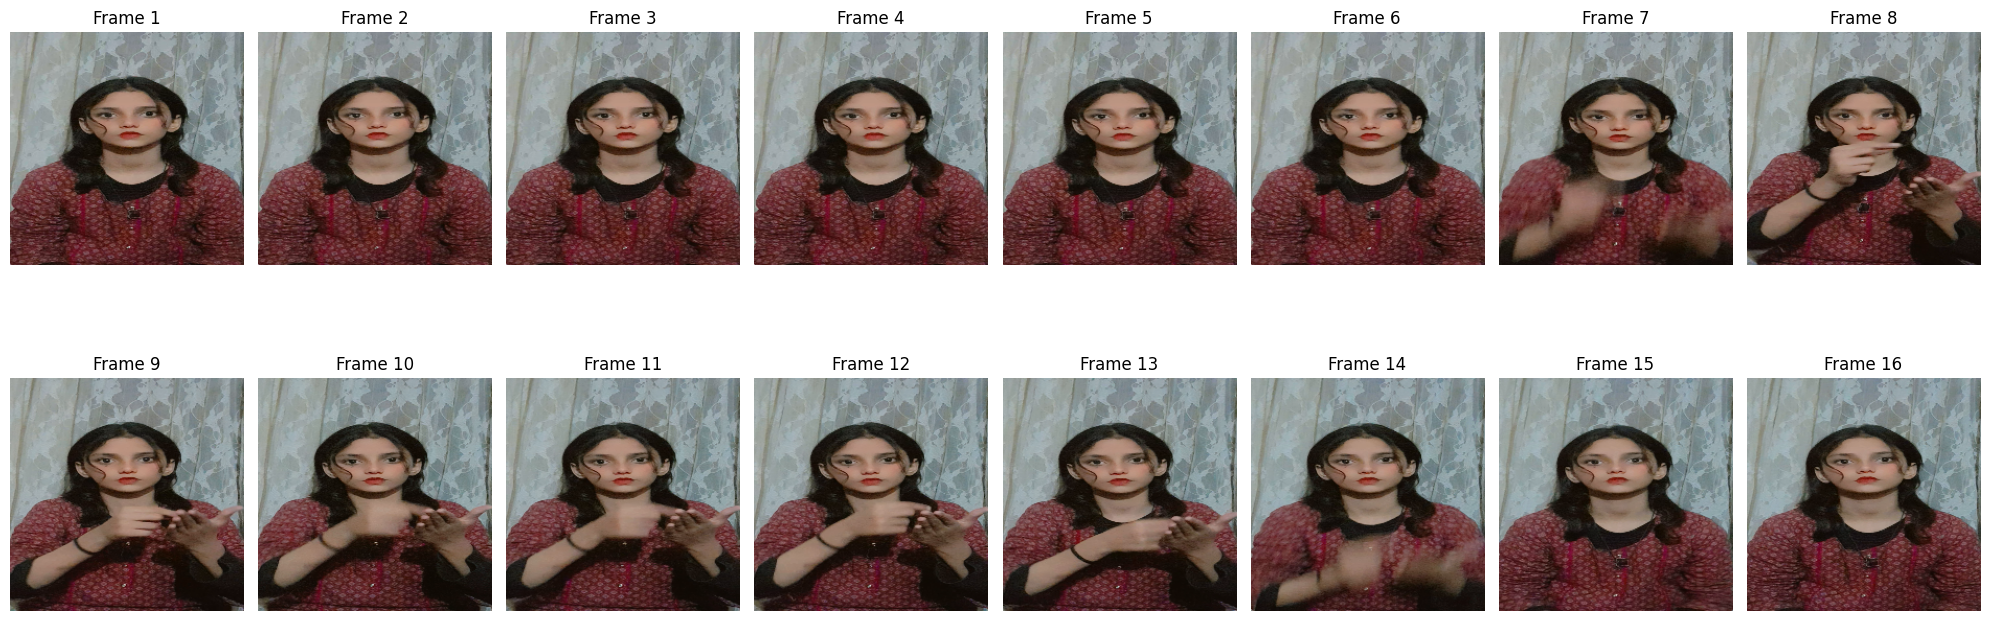

In [5]:
import matplotlib.pyplot as plt
import random
import os
import numpy as np

def visualize_processed_rgb(): 
    base_path = '/kaggle/working/processed_sign_data/train'
    all_classes = os.listdir(base_path)
    
    random_cls = random.choice(all_classes)
    random_file = random.choice(os.listdir(os.path.join(base_path, random_cls)))
    file_path = os.path.join(base_path, random_cls, random_file)
    
    loaded = np.load(file_path)
    frames = loaded['data']  
    label = loaded['label']
    
    print(f"Showing Sign: {random_cls} (Label: {label})")
    print(f"Data Shape: {frames.shape}") 

    plt.figure(figsize=(20, 8))
    for i in range(16): # Now showing 16 frames
        plt.subplot(2, 8, i + 1)
        plt.imshow(frames[i].astype('float32')) 
        plt.title(f"Frame {i+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_processed_rgb()

In [6]:
import os
import numpy as np
import pandas as pd
from tabulate import tabulate # Agar error de to !pip install tabulate kar lein

def audit_dataset_research_v3():
    processed_base = '/kaggle/working/processed_sign_data'
    master_map_path = '/kaggle/working/master_label_map.npy'
    
    if not os.path.exists(processed_base):
        print("Error: Processed data folder nahi mila!")
        return

    # 1. Master Label Map Load Karein
    label_map = np.load(master_map_path, allow_pickle=True).item()
    classes = sorted(label_map.keys())
    
    stats = []
    total_train, total_val, total_test = 0, 0, 0

    print("-" * 60)
    print(f" DATASET AUDIT REPORT (Total Classes: {len(classes)})")
    print("-" * 60)

    # 2. Har class ki distribution check karein
    for cls in classes:
        train_count = len(os.listdir(os.path.join(processed_base, 'train', cls))) if os.path.exists(os.path.join(processed_base, 'train', cls)) else 0
        val_count = len(os.listdir(os.path.join(processed_base, 'val', cls))) if os.path.exists(os.path.join(processed_base, 'val', cls)) else 0
        test_count = len(os.listdir(os.path.join(processed_base, 'test', cls))) if os.path.exists(os.path.join(processed_base, 'test', cls)) else 0
        
        row_total = train_count + val_count + test_count
        stats.append([label_map[cls], cls, train_count, val_count, test_count, row_total])
        
        total_train += train_count
        total_val += val_count
        total_test += test_count

    # 3. Table Format mein Show karein
    headers = ["ID", "Word/Class", "Train", "Val", "Test", "Total Per Class"]
    print(tabulate(stats, headers=headers, tablefmt="grid"))

    # 4. Final Summary Statistics
    grand_total = total_train + total_val + total_test
    print("\n" + "="*40)
    print(f" FINAL SUMMARY")
    print("="*40)
    print(f"Total Processed Videos: {grand_total}")
    print(f"Total Training:         {total_train} ({round(total_train/grand_total*100, 1)}%)")
    print(f"Total Validation:       {total_val} ({round(total_val/grand_total*100, 1)}%)")
    print(f"Total Testing:          {total_test} ({round(total_test/grand_total*100, 1)}%)")
    
    # 5. Balance Check Alert
    counts = [row[5] for row in stats]
    if len(set(counts)) == 1:
        print("\n Dataset is Perfectly Balanced (All classes have same number of videos).")
    else:
        print(f"\n Dataset is Imbalanced. Max: {max(counts)} | Min: {min(counts)}")
    print("="*40)

# Run the Audit
audit_dataset_research_v3()

------------------------------------------------------------
 DATASET AUDIT REPORT (Total Classes: 50)
------------------------------------------------------------
+------+--------------+---------+-------+--------+-------------------+
|   ID | Word/Class   |   Train |   Val |   Test |   Total Per Class |
+======+==============+=========+=======+========+===================+
|    0 | aaj          |      56 |    12 |     12 |                80 |
+------+--------------+---------+-------+--------+-------------------+
|    1 | aath         |      56 |    12 |     12 |                80 |
+------+--------------+---------+-------+--------+-------------------+
|    2 | ahista       |      56 |    12 |     12 |                80 |
+------+--------------+---------+-------+--------+-------------------+
|    3 | anywalakal   |      56 |    12 |     12 |                80 |
+------+--------------+---------+-------+--------+-------------------+
|    4 | behtreen     |      56 |    12 |     12 |     

In [7]:
import os
import zipfile
import math
from IPython.display import FileLink, display

source_dir = '/kaggle/working/processed_sign_data'
working_dir = '/kaggle/working'

# 1. Purani zip files saaf karein taake storage full na ho
print("Cleaning up old zip archives...")
for f in os.listdir(working_dir):
    if f.startswith('SignSpeak_v3_') and f.endswith('.zip'):
        os.remove(os.path.join(working_dir, f))

def create_zip_chunks(folder_path, split_name, num_chunks=3):
    """
    Folder ki classes ko evenly divide kar ke multiple zip files banata hai.
    """
    if not os.path.exists(folder_path):
        return []
        
    classes = sorted(os.listdir(folder_path))
    # Calculate kitni classes aik zip file mein jayengi
    chunk_size = math.ceil(len(classes) / num_chunks)
    links = []
    
    for i in range(num_chunks):
        chunk_classes = classes[i * chunk_size : (i + 1) * chunk_size]
        if not chunk_classes:
            continue
            
        zip_filename = f'SignSpeak_v3_{split_name}_part{i+1}.zip'
        zip_path = os.path.join(working_dir, zip_filename)
        
        print(f"Creating {zip_filename} (Classes included: {len(chunk_classes)})...")
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for cls in chunk_classes:
                cls_path = os.path.join(folder_path, cls)
                if not os.path.isdir(cls_path): continue
                
                for file in os.listdir(cls_path):
                    file_path = os.path.join(cls_path, file)
                    # Folder structure maintain rakhne ke liye arcname set kiya
                    arcname = os.path.join(split_name, cls, file)
                    zipf.write(file_path, arcname)
        
        links.append(zip_filename)
    return links

# 2. Data ko wisely chunks mein zip karein
print("Zipping Training Data (Dividing into 3 parts to avoid download crashes)...")
train_zips = create_zip_chunks(os.path.join(source_dir, 'train'), 'train', num_chunks=3)

print("\nZipping Validation and Test Data...")
# Val aur Test chotay hotay hain, is liye inka 1 hi chunk kaafi hai
val_zips = create_zip_chunks(os.path.join(source_dir, 'val'), 'val', num_chunks=1)
test_zips = create_zip_chunks(os.path.join(source_dir, 'test'), 'test', num_chunks=1)

# 3. Har part ka alag download link generate karein
print("\n--- SECURE DOWNLOAD LINKS ---")
print("Apne PC par save karne ke liye in links par bari bari click karein:")
all_zips = train_zips + val_zips + test_zips
for zip_file in all_zips:
    display(FileLink(zip_file))

Cleaning up old zip archives...
Zipping Training Data (Dividing into 3 parts to avoid download crashes)...
Creating SignSpeak_v3_train_part1.zip (Classes included: 17)...
Creating SignSpeak_v3_train_part2.zip (Classes included: 17)...
Creating SignSpeak_v3_train_part3.zip (Classes included: 16)...

Zipping Validation and Test Data...
Creating SignSpeak_v3_val_part1.zip (Classes included: 50)...
Creating SignSpeak_v3_test_part1.zip (Classes included: 50)...

--- SECURE DOWNLOAD LINKS ---
Apne PC par save karne ke liye in links par bari bari click karein:


/kaggle/working/SignSpeak_v3_train_part1.zip

/kaggle/working/SignSpeak_v3_train_part2.zip

/kaggle/working/SignSpeak_v3_train_part3.zip

/kaggle/working/SignSpeak_v3_val_part1.zip

/kaggle/working/SignSpeak_v3_test_part1.zip

In [8]:
import os
import cv2
import random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import numpy as np

class SafeAugmentedSignDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_path, batch_size=8, augment=False):
        self.base_path = base_path
        self.batch_size = batch_size
        self.augment = augment
        self.file_list = []
        
        for cls in sorted(os.listdir(base_path)):
            cls_path = os.path.join(base_path, cls)
            if os.path.isdir(cls_path):
                for f in os.listdir(cls_path):
                    if f.endswith('.npz'):
                        self.file_list.append(os.path.join(cls_path, f))
        
        self.indexes = np.arange(len(self.file_list))

    def __len__(self):
        return int(np.floor(len(self.file_list) / self.batch_size))

    def augment_sequence(self, frames):
        # Reference notebook wali safe augmentations
        frames = frames.copy()
        h, w, c = frames[0].shape

        brightness_factor = random.uniform(0.82, 1.18)
        contrast_factor = random.uniform(0.82, 1.18)
        zoom_factor = random.uniform(0.92, 1.08)
        shift_x = random.randint(int(-0.08 * w), int(0.08 * w))
        shift_y = random.randint(int(-0.08 * h), int(0.08 * h))
        apply_blur = random.random() < 0.35

        aug_frames = []
        for frame in frames:
            img = frame.astype(np.float32)
            
            img = img * brightness_factor # Brightness
            
            mean = np.mean(img, axis=(0, 1), keepdims=True)
            img = (img - mean) * contrast_factor + mean # Contrast
            
            if zoom_factor != 1.0: # Slight Zoom
                new_h, new_w = max(1, int(h / zoom_factor)), max(1, int(w / zoom_factor))
                y1, x1 = max((h - new_h) // 2, 0), max((w - new_w) // 2, 0)
                cropped = img[y1:y1 + new_h, x1:x1 + new_w]
                img = cv2.resize(cropped, (w, h))
                
            M = np.float32([[1, 0, shift_x], [0, 1, shift_y]]) # Slight Shift
            img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
            
            if apply_blur: # Mild Blur
                img = cv2.GaussianBlur(img, (3, 3), 0)

            img = np.clip(img, 0.0, 1.0).astype(np.float32)
            aug_frames.append(img)

        return np.array(aug_frames, dtype=np.float32)

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size]
        batch_files = [self.file_list[k] for k in indexes]
        
        X, y = [], []
        for file in batch_files:
            try:
                loaded = np.load(file)
                data = loaded['data'].astype(np.float32) 
                label = int(loaded['label'])
                
                if self.augment:
                    data = self.augment_sequence(data)
                
                X.append(data)
                y.append(label)
            except Exception as e:
                continue
            
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

    def on_epoch_end(self):
        np.random.shuffle(self.indexes)

train_gen = SafeAugmentedSignDataGenerator('/kaggle/working/processed_sign_data/train', batch_size=8, augment=True)
val_gen = SafeAugmentedSignDataGenerator('/kaggle/working/processed_sign_data/val', batch_size=8, augment=False)
test_gen = SafeAugmentedSignDataGenerator('/kaggle/working/processed_sign_data/test', batch_size=8, augment=False)

print(f"Batches per epoch - Train: {len(train_gen)}, Val: {len(val_gen)}, Test: {len(test_gen)}")

E0000 00:00:1775675926.817858      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775675926.867829      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775675927.278195      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775675927.278224      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775675927.278227      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775675927.278229      24 computation_placer.cc:177] computation placer already registered. Please check linka

Batches per epoch - Train: 350, Val: 75, Test: 75


In [9]:
from tensorflow.keras import layers, models, optimizers, regularizers

def build_improved_model(num_classes):
    base_cnn = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    
    base_cnn.trainable = True 
    for layer in base_cnn.layers[:100]:
        layer.trainable = False

    # Updated to 16 frames
    inputs = layers.Input(shape=(16, 224, 224, 3))
    
    x = layers.TimeDistributed(base_cnn)(inputs)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    x = layers.TimeDistributed(layers.Dropout(0.25))(x) # Added dropout here
    
    # BiLSTM with Recurrent Dropout for research-grade sequential modeling
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False, dropout=0.25, recurrent_dropout=0.2))(x) 
    x = layers.BatchNormalization()(x) 
    
    # Added L2 Regularizer to strictly control overfitting
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x) # Increased dropout
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4), 
                  loss=loss_fn, 
                  metrics=['accuracy'])
    return model

label_map = np.load('/kaggle/working/master_label_map.npy', allow_pickle=True).item()
model = build_improved_model(len(label_map))
model.summary()

I0000 00:00:1775675950.376316      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775675950.382537      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 7, 7, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,780,466 (14.42 MB)

 Trainable params: 3,383,410 (12.91 MB)

 Non-trainable params: 397,056 (1.51 MB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("Starting Improved Training for Big Dataset...")

# Keras 3 mein workers/multiprocessing ki zaroorat nahi, yeh auto-handled hai
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50, 
    callbacks=callbacks
)

Starting Improved Training for Big Dataset...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1775676058.974290   28079 cuda_dnn.cc:529] Loaded cuDNN version 91002


350/350 ━━━━━━━━━━━━━━━━━━━━ 442s 958ms/step - accuracy: 0.0279 - loss: 4.4722 - val_accuracy: 0.0250 - val_loss: 4.0250 - learning_rate: 1.0000e-04
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 308s 880ms/step - accuracy: 0.0313 - loss: 4.2117 - val_accuracy: 0.0383 - val_loss: 3.9197 - learning_rate: 1.0000e-04
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 313s 893ms/step - accuracy: 0.0556 - loss: 3.9747 - val_accuracy: 0.0650 - val_loss: 3.5932 - learning_rate: 1.0000e-04
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 309s 881ms/step - accuracy: 0.0744 - loss: 3.6996 - val_accuracy: 0.1633 - val_loss: 3.1901 - learning_rate: 1.0000e-04
Epoch 5/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 312s 890ms/step - accuracy: 0.1454 - loss: 3.4007 - val_accuracy: 0.2333 - val_loss: 2.7336 - learning_rate: 1.0000e-04
Epoch 6/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 310s 886ms/step - accuracy: 0.2104 - loss: 2.9939 - val_accuracy: 0.3717 - val_loss: 2.2855 - learning_rate: 1.0000e-04
Epoch 7/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 309s 881ms/

In [11]:
import pickle
import numpy as np
from IPython.display import FileLink, display

# 1. Model Save (Save karte waqt poora path theek hai)
model.save('/kaggle/working/SignSpeak_Model_Final.keras')

# 2. Label Map Save
label_map = np.load('/kaggle/working/master_label_map.npy', allow_pickle=True).item()
with open('/kaggle/working/master_label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

print("Files saved successfully!")
print("\n--- DOWNLOAD LINKS ---")

# FIX: Yahan sirf file ka naam dena hai
display(FileLink('SignSpeak_Model_Final.keras'))
display(FileLink('master_label_map.pkl'))

Files saved successfully!

--- DOWNLOAD LINKS ---


/kaggle/working/SignSpeak_Model_Final.keras

/kaggle/working/master_label_map.pkl

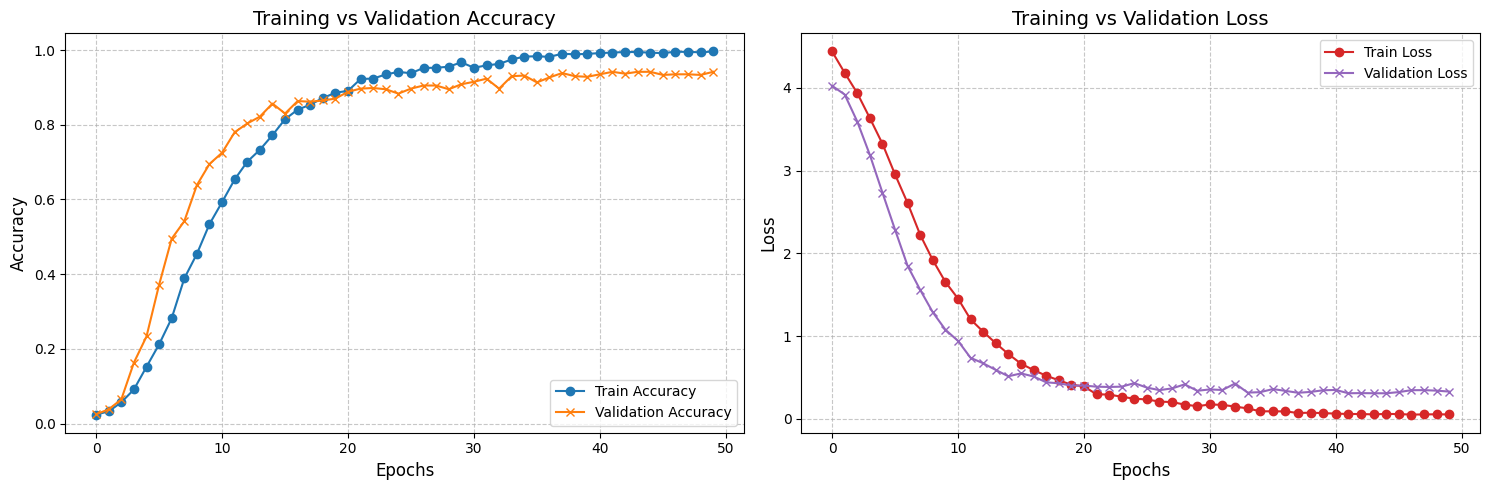

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='#1f77b4')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x', color='#ff7f0e')
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', color='#d62728')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x', color='#9467bd')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Generating predictions using generator (Fast Method)...


Predicting Test Data: 100%|██████████| 75/75 [01:29<00:00,  1.19s/it]



Final Train Acc: 99.61%
Final Val Acc:   94.17%
Final Test Acc:  93.50%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         aaj       1.00      0.83      0.91        12
        aath       0.92      0.92      0.92        12
      ahista       1.00      0.92      0.96        12
  anywalakal       1.00      0.83      0.91        12
    behtreen       1.00      1.00      1.00        12
       btana       1.00      0.92      0.96        12
      bukhar       0.83      0.83      0.83        12
         bus       1.00      0.83      0.91        12
         car       1.00      1.00      1.00        12
        char       0.69      0.92      0.79        12
      chawal       0.92      1.00      0.96        12
        chay       0.92      1.00      0.96        12
       chaye       1.00      0.67      0.80        12
       chini       1.00      0.92      0.96        12
        dard       1.00      1.00      1.00        12
         das       0.8

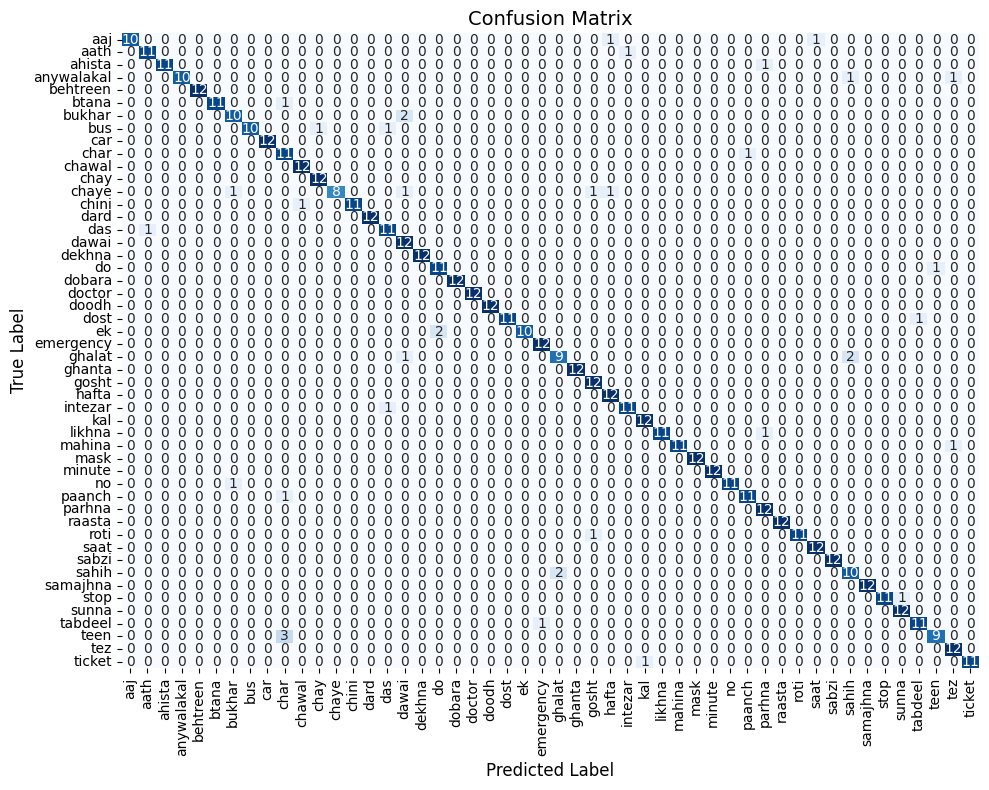

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

def evaluate_big_dataset(model, test_generator, history):
    print("Generating predictions using generator (Fast Method)...")
    y_true = []
    y_pred = []
    
    # Batches ke through fast prediction
    for i in tqdm(range(len(test_generator)), desc="Predicting Test Data"):
        X_batch, y_batch = test_generator[i]
        preds = model.predict(X_batch, verbose=0)
        y_true.extend(y_batch)
        y_pred.extend(np.argmax(preds, axis=1))
        
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Accuracy Calculations
    test_acc = np.mean(y_true == y_pred)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    
    print("\n" + "="*35)
    print(f"Final Train Acc: {train_acc*100:.2f}%")
    print(f"Final Val Acc:   {val_acc*100:.2f}%")
    print(f"Final Test Acc:  {test_acc*100:.2f}%")
    print("="*35)

    # Label Names Fetch karna
    label_map = np.load('/kaggle/working/master_label_map.npy', allow_pickle=True).item()
    inv_label_map = {v: k for k, v in label_map.items()}
    class_names = [inv_label_map[i] for i in range(len(inv_label_map))]
    
    print("\n--- Detailed Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix Visual
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=90) # Text overlap se bachne ke liye
    plt.tight_layout()
    plt.show()

# Isko run karein
evaluate_big_dataset(model, test_gen, history)

Testing set par predictions li ja rahi hain...


<Figure size 2000x700 with 0 Axes>

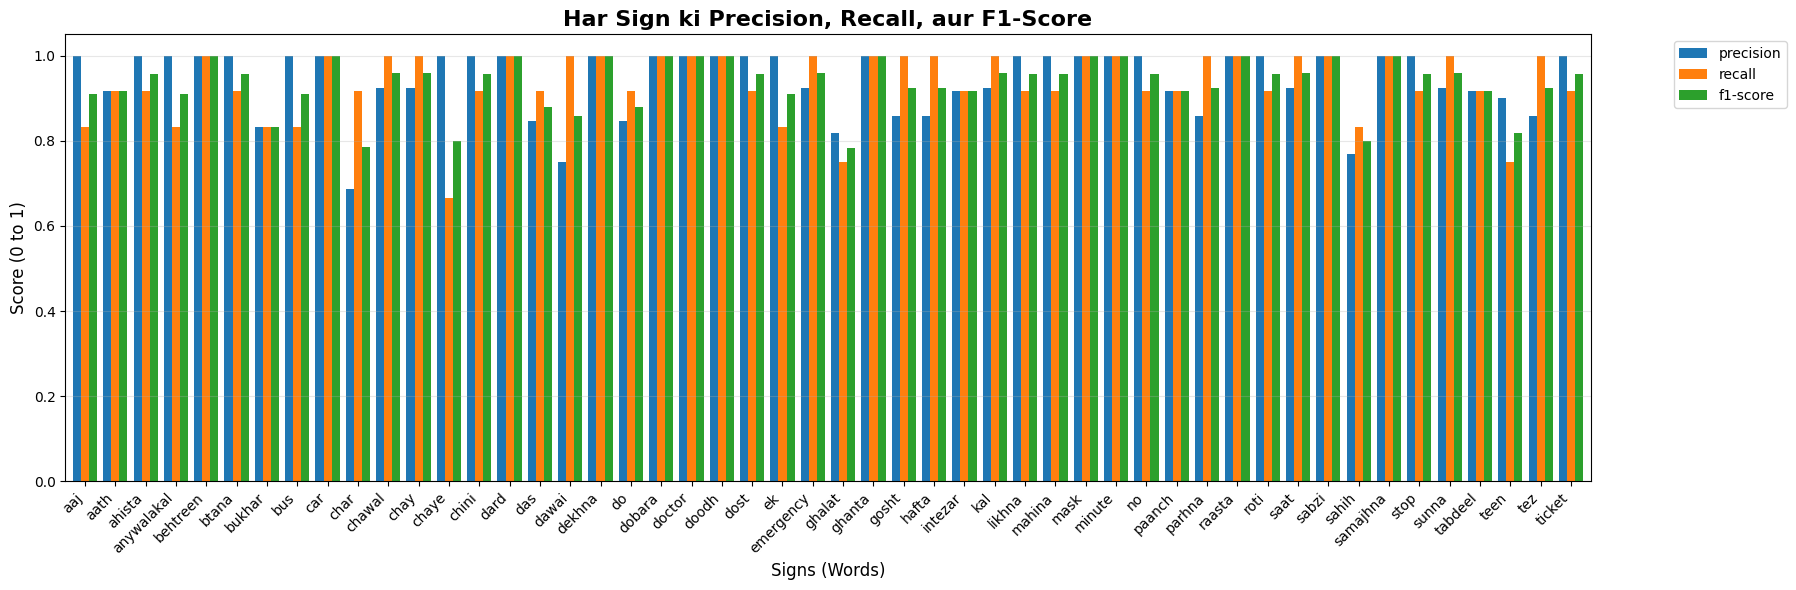

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# 1. Predictions calculate karein
print("Testing set par predictions li ja rahi hain...")
y_true = []
y_pred = []

for i in range(len(test_gen)):
    x, y = test_gen[i]
    predictions = model.predict(x, verbose=0)
    y_true.extend(y)
    y_pred.extend(np.argmax(predictions, axis=1))

# 2. Names nikalne ke liye label map use karein
inv_label_map = {v: k for k, v in label_map.items()}
class_names = [inv_label_map[i] for i in range(len(label_map))]

# 3. Report generate karke plot karein
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:-3, :] # accuracy/macro rows hata dein

plt.figure(figsize=(20, 7))
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(18, 6), width=0.8)
plt.title('Har Sign ki Precision, Recall, aur F1-Score', fontsize=16, fontweight='bold')
plt.xlabel('Signs (Words)', fontsize=12)
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

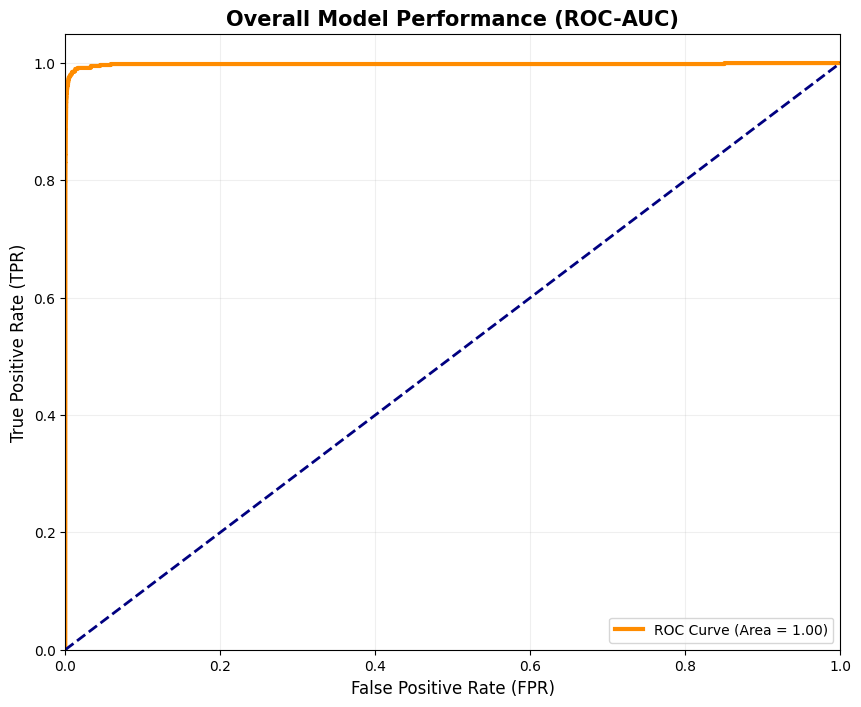

Model ka Total AUC Score: 0.9979


In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Labels ko binarize karein (Multi-class ROC ke liye zaroori hai)
y_true_array = np.array(y_true)
y_true_bin = label_binarize(y_true_array, classes=range(len(class_names)))

# Dubara prediction probs leni parengi agar pehle save nahi kin
y_pred_probs = []
for i in range(len(test_gen)):
    x, _ = test_gen[i]
    probs = model.predict(x, verbose=0)
    y_pred_probs.extend(probs)
y_pred_probs = np.array(y_pred_probs)

# Micro-average calculate karein
fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (Area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Overall Model Performance (ROC-AUC)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

print(f"Model ka Total AUC Score: {roc_auc:.4f}")

In [16]:
import cv2
import numpy as np
import os
import random

def deployment_test(num_samples=10):
    # 1. Dataset ka asli path (jahan mp4 videos hain)
    raw_data_path = '/kaggle/input/datasets/hasnainsharfa/usl-signsspeak/SignSpeak_Dataset'
    
    # Label map load karein
    inv_label_map = {v: k for k, v in label_map.items()}
    all_classes = list(label_map.keys())
    
    correct = 0
    print(f"--- Running Deployment Stress Test on {num_samples} Raw Videos ---\n")

    for _ in range(num_samples):
        # Randomly ek class aur video uthayen
        actual_class = random.choice(all_classes)
        class_folder = os.path.join(raw_data_path, actual_class)
        video_name = random.choice(os.listdir(class_folder))
        video_path = os.path.join(class_folder, video_name)

        # 2. Raw Video Processing (Exactly like your local script)
        cap = cv2.VideoCapture(video_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            # Note: Yahan hum GaussianBlur wahi rakh rahe hain jo training mein tha
            frame = cv2.GaussianBlur(frame, (3, 3), 0)
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame / 255.0)
        cap.release()

        if len(frames) < 16: continue

        # 16 frames extract karein (Uniform Sampling)
        idx = np.linspace(0, len(frames) - 1, 16, dtype=int)
        input_data = np.array([frames[i] for i in idx])
        input_data = np.expand_dims(input_data, axis=0) # Batch dimension

        # 3. Model Prediction
        pred_probs = model.predict(input_data, verbose=0)
        pred_idx = np.argmax(pred_probs)
        predicted_class = inv_label_map[pred_idx]
        confidence = np.max(pred_probs) * 100

        status = "✅ MATCH" if predicted_class == actual_class else "❌ WRONG"
        if predicted_class == actual_class: correct += 1

        print(f"Video: {video_name} | Actual: {actual_class}")
        print(f"Pred: {predicted_class} ({confidence:.2f}%) | {status}\n")

    print(f"Final Stress Test Accuracy: {(correct/num_samples)*100}%")

# Test run karein
deployment_test(num_samples=15)

--- Running Deployment Stress Test on 15 Raw Videos ---

Video: video_20260309_131205.mp4 | Actual: sabzi
Pred: sabzi (100.00%) | ✅ MATCH

Video: kal_07.MOV | Actual: kal
Pred: kal (100.00%) | ✅ MATCH

Video: IMG_4755.MOV | Actual: das
Pred: das (100.00%) | ✅ MATCH

Video: tabdeel_04.MOV | Actual: tabdeel
Pred: tabdeel (99.99%) | ✅ MATCH

Video: VID-20251113-WA0190.mp4 | Actual: ahista
Pred: ahista (100.00%) | ✅ MATCH

Video: IMG_4729.MOV | Actual: sabzi
Pred: sabzi (100.00%) | ✅ MATCH

Video: 20260310_141910.mp4 | Actual: tabdeel
Pred: tabdeel (99.99%) | ✅ MATCH

Video: VID-20251113-WA0158.mp4 | Actual: hafta
Pred: hafta (100.00%) | ✅ MATCH

Video: mahina_05.MOV | Actual: mahina
Pred: mahina (99.99%) | ✅ MATCH

Video: ahista_18.MOV | Actual: ahista
Pred: ahista (100.00%) | ✅ MATCH

Video: IMG_4426.MOV | Actual: mahina
Pred: mahina (100.00%) | ✅ MATCH

Video: 20251202_161235.mp4 | Actual: btana
Pred: btana (99.66%) | ✅ MATCH

Video: video_20260309_142822.mp4 | Actual: emergency
Pred: e